In [1]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
def use_svg_display():
    matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
def set_figsize(figsize=(3.5, 2.5), fontsize=10):
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize
    plt.rcParams['font.size'] = fontsize
set_figsize()

# plt.rc('font',family='SimHei')  #用来 Windows 正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] #用来 MacOS 正常显示中文标签

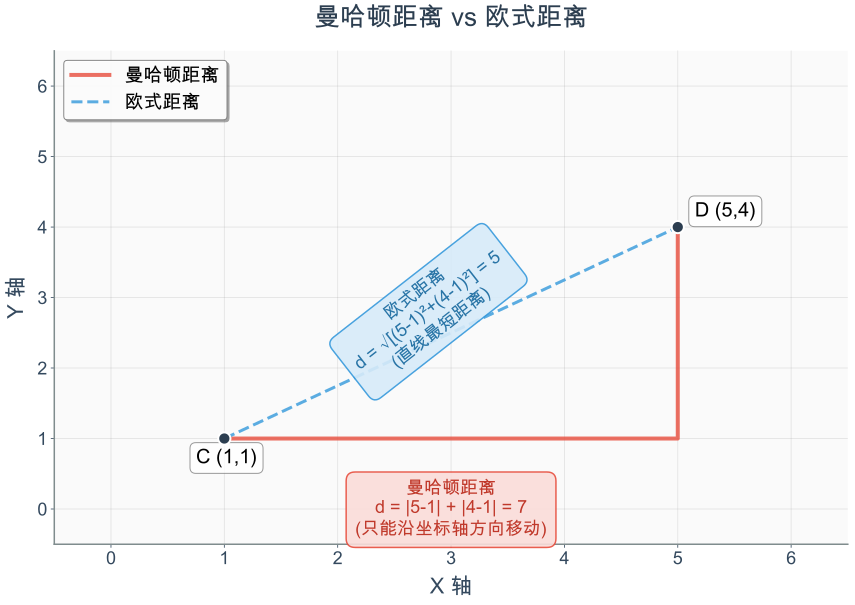

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import os

# 设置中文显示为常用字体（黑体/无衬线字体）
# 优先使用 Noto Sans CJK（黑体），这是更常用的中文字体
font_paths = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
]

font_prop = None
font_name = None

for font_path in font_paths:
    if os.path.exists(font_path):
        try:
            font_prop = fm.FontProperties(fname=font_path)
            font_name = font_prop.get_name()
            break
        except:
            continue

# 设置全局字体
if font_prop is not None and font_name:
    plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif']
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"已设置字体: {font_name}")
else:
    # 备用方案：通过字体名称查找
    sans_fonts = ['Noto Sans CJK SC', 'Noto Sans CJK TC', 'Noto Sans CJK JP', 'WenQuanYi Micro Hei']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    for font in sans_fonts:
        if font in available_fonts:
            plt.rcParams['font.sans-serif'] = [font] + plt.rcParams['font.sans-serif']
            plt.rcParams['font.family'] = 'sans-serif'
            print(f"使用字体: {font}")
            break

plt.rcParams['axes.unicode_minus'] = False

# 创建图形，优化尺寸和样式
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('white')

# 1. 定义点坐标
C = (1, 1)
D = (5, 4)

# 2. 绘制曼哈顿距离 (使用更现代的颜色)
# 路径：(1,1) -> (5,1) -> (5,4)
manhattan_x = [C[0], D[0], D[0]]
manhattan_y = [C[1], C[1], D[1]]
ax.plot(manhattan_x, manhattan_y, color='#E74C3C', linewidth=4, 
        label='曼哈顿距离', zorder=2, alpha=0.8)

# 3. 绘制欧式距离 (使用更现代的颜色)
ax.plot([C[0], D[0]], [C[1], D[1]], color='#3498DB', linestyle='--', 
        linewidth=3, label='欧式距离', zorder=2, alpha=0.8)

# 绘制点 C 和 D，使用更大的点和更好的样式
ax.scatter([C[0], D[0]], [C[1], D[1]], color='#2C3E50', s=150, 
          zorder=5, edgecolors='white', linewidths=2)
ax.text(C[0]-0.25, C[1]-0.35, 'C (1,1)', fontsize=20, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))
ax.text(D[0]+0.15, D[1]+0.15, 'D (5,4)', fontsize=20, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

# 4. 公式标注与文字说明 - 优化位置和样式
# 曼哈顿距离说明
ax.text(3, 0.4, '曼哈顿距离\nd = |5-1| + |4-1| = 7\n(只能沿坐标轴方向移动)', 
        color='#C0392B', fontsize=18, ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FADBD8', alpha=0.9, 
                 edgecolor='#E74C3C', linewidth=1.5))

# 欧式距离说明 - 调整位置使其更靠近蓝色虚线
# 蓝色虚线从(1,1)到(5,4)，中点在(3, 2.5)，调整位置更靠近线
ax.text(2.8, 2.8, '欧式距离\nd = √[(5-1)²+(4-1)²] = 5\n(直线最短距离)', 
        color='#2874A6', fontsize=18, rotation=38, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#D6EAF8', alpha=0.9,
                 edgecolor='#3498DB', linewidth=1.5))

# 5. 设置坐标轴和网格 - 优化样式
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 6.5)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.grid(True, linestyle='-', alpha=0.2, color='gray', linewidth=0.8)
ax.set_facecolor('#FAFAFA')  # 浅灰色背景

# 坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#7F8C8D')
ax.spines['bottom'].set_color('#7F8C8D')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_xlabel('X 轴', fontsize=22, color='#34495E', fontweight='bold', labelpad=10)
ax.set_ylabel('Y 轴', fontsize=22, color='#34495E', fontweight='bold', labelpad=10)
ax.set_title('曼哈顿距离 vs 欧式距离', fontsize=26, pad=25, 
             color='#2C3E50', fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=18, colors='#34495E')

# 6. 图例 - 优化样式和位置
ax.legend(loc='upper left', frameon=True, fontsize=19, 
         framealpha=0.95, edgecolor='gray', facecolor='white',
         shadow=True, fancybox=True)

# 7. 应用场景标注 - 优化样式


plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

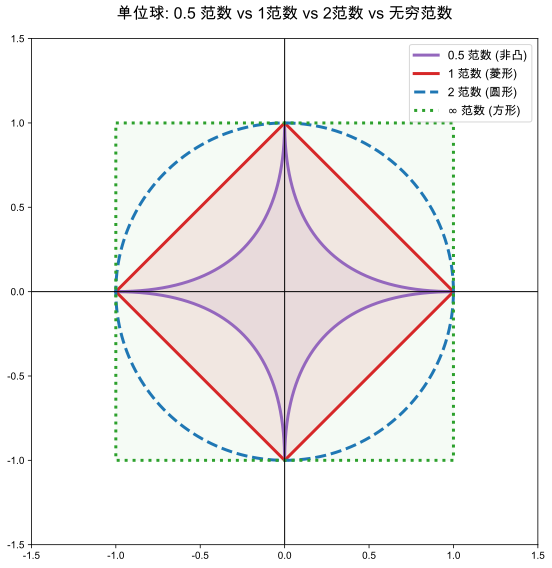

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 设置绘图风格 (可选，为了更好看)
# plt.style.use('seaborn-v0_8-whitegrid')

# 创建画布
plt.figure(figsize=(8, 8), dpi=150)
ax = plt.gca()

# --- 4. 非凸范数 p=0.5 ---
x = np.linspace(-1, 1, 7000)
y_pos = (1 - np.abs(x)**0.5)**2
y_neg = -y_pos

ax.plot(x, y_pos, color='#9467bd', linewidth=3, label='0.5 范数 (非凸)')
ax.plot(x, y_neg, color='#9467bd', linewidth=3)
ax.fill_between(x, y_pos, y_neg, color='#9467bd', alpha=0.1)

# --- 1. L1 范数 (菱形) ---
# |x| + |y| = 1
l1_x = [0, 1, 0, -1, 0]
l1_y = [1, 0, -1, 0, 1]
ax.plot(l1_x, l1_y, color='#d62728', linewidth=3, label='1 范数 (菱形)')
ax.fill(l1_x, l1_y, color='#d62728', alpha=0.1) # 填充颜色

# --- 2. L2 范数 (圆形) ---
# x^2 + y^2 = 1
theta = np.linspace(0, 2*np.pi, 200)
l2_x = np.cos(theta)
l2_y = np.sin(theta)
ax.plot(l2_x, l2_y, color='#1f77b4', linewidth=3, linestyle='--', label='2 范数 (圆形)')
# ax.fill(l2_x, l2_y, color='#1f77b4', alpha=0.05) 

# --- 3. L-infinity 范数 (正方形) ---
# max(|x|, |y|) = 1
linf_x = [-1, 1, 1, -1, -1]
linf_y = [1, 1, -1, -1, 1]
ax.plot(linf_x, linf_y, color='#2ca02c', linewidth=3, linestyle=':', label=r'$\infty$ 范数 (方形)')
ax.fill(linf_x, linf_y, color='#2ca02c', alpha=0.05)



# --- 装饰与标注 ---
ax.axhline(0, color='black', linewidth=1) # x轴
ax.axvline(0, color='black', linewidth=1) # y轴

# 设置坐标范围和比例
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal') # 关键！保证圆是圆，不是椭圆

# 标题与图例
plt.title('单位球: 0.5 范数 vs 1范数 vs 2范数 vs 无穷范数', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='upper right', frameon=True)

# 标注文字 (解释用)
# plt.text(0.6, 0.6, 'L1 有尖角\n(稀疏性)', color='#d62728', fontsize=10, ha='center')
# plt.text(1.1, 1.1, r'$L_\infty$ 方形', color='#2ca02c', fontsize=10)

plt.tight_layout()
plt.show()

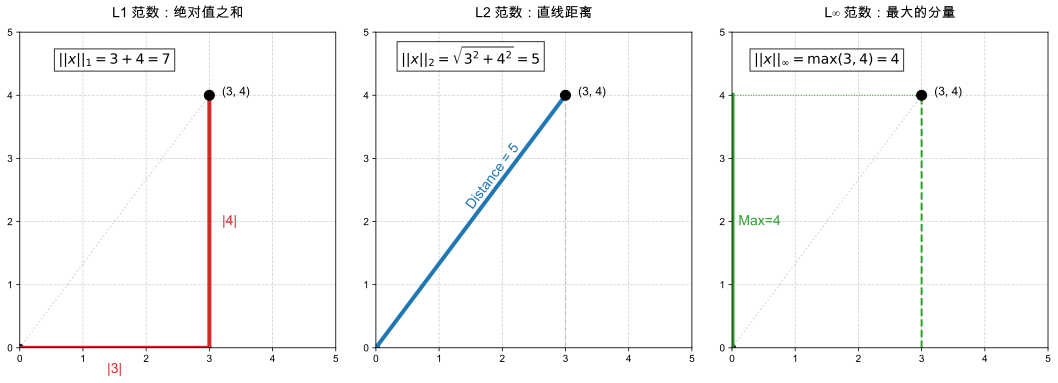

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图风格，适合PPT展示
# plt.style.use('seaborn-v0_8-whitegrid')

# 创建画布：1行3列
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
vector = np.array([3, 4]) # 使用经典的勾股数向量 (3, 4)

# 公共设置函数
def setup_plot(ax, title):
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, linestyle='--', alpha=0.6)
    # 画出向量的终点
    ax.scatter(vector[0], vector[1], color='black', s=100, zorder=5)
    ax.text(vector[0]+0.2, vector[1], '(3, 4)', fontsize=12)
    # 画原点
    ax.scatter(0, 0, color='black', s=50)

# --- 图 1: L1 范数 (曼哈顿距离) ---
ax1 = axes[0]
setup_plot(ax1, "L1 范数：绝对值之和")
# 画路径：先X后Y
ax1.plot([0, 3], [0, 0], color='#d62728', linewidth=4, label='x component')
ax1.plot([3, 3], [0, 4], color='#d62728', linewidth=4, linestyle='-', label='y component')
# 虚线连接原点到终点作为参考
ax1.plot([0, 3], [0, 4], color='gray', linestyle=':', alpha=0.3)
# 标注
ax1.text(1.5, -0.4, '|3|', color='#d62728', fontsize=14, ha='center', fontweight='bold')
ax1.text(3.2, 2, '|4|', color='#d62728', fontsize=14, va='center', fontweight='bold')
ax1.text(1.5, 4.5, r'$||x||_1 = 3 + 4 = 7$', fontsize=14, color='black', ha='center', bbox=dict(facecolor='white', alpha=0.8))


# --- 图 2: L2 范数 (欧几里得距离) ---
ax2 = axes[1]
setup_plot(ax2, "L2 范数：直线距离")
# 画直线路径
ax2.plot([0, 3], [0, 4], color='#1f77b4', linewidth=4)
# 辅助线
ax2.plot([0, 3], [0, 0], color='gray', linestyle='--', alpha=0.3)
ax2.plot([3, 3], [0, 4], color='gray', linestyle='--', alpha=0.3)
# 标注
ax2.text(1.4, 2.2, 'Distance = 5', color='#1f77b4', fontsize=14, rotation=53, fontweight='bold')
ax2.text(1.5, 4.5, r'$||x||_2 = \sqrt{3^2 + 4^2} = 5$', fontsize=14, color='black', ha='center', bbox=dict(facecolor='white', alpha=0.8))


# --- 图 3: L∞ 范数 (最大值) ---
ax3 = axes[2]
setup_plot(ax3, "L∞ 范数：最大的分量")
# 画向量参考
ax3.plot([0, 3], [0, 4], color='gray', linestyle=':', alpha=0.3)
# 强调最大的分量 (Y轴分量)
ax3.plot([0, 0], [0, 4], color='#2ca02c', linewidth=5, linestyle='-') # 在Y轴上展示投影
ax3.plot([3, 3], [0, 4], color='#2ca02c', linewidth=2, linestyle='--') # 对应位置
ax3.plot([0, 3], [4, 4], color='#2ca02c', linewidth=1, linestyle=':') # 投影线
# 标注
ax3.text(0.1, 2, 'Max=4', color='#2ca02c', fontsize=14, va='center', fontweight='bold')
ax3.text(1.5, 4.5, r'$||x||_\infty = \max(3, 4) = 4$', fontsize=14, color='black', ha='center', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

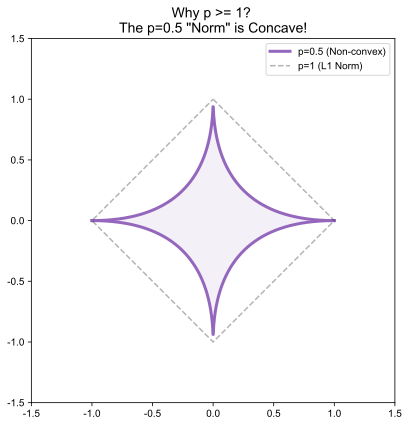

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(6, 6), dpi=150)
ax = plt.gca()

# 绘制 p=0.5 的单位球: |x|^0.5 + |y|^0.5 = 1
# 也就是 y = (1 - |x|^0.5)^2
x = np.linspace(-1, 1, 1000)
y_pos = (1 - np.abs(x)**0.5)**2
y_neg = -y_pos

ax.plot(x, y_pos, color='#9467bd', linewidth=3, label='p=0.5 (Non-convex)')
ax.plot(x, y_neg, color='#9467bd', linewidth=3)
ax.fill_between(x, y_pos, y_neg, color='#9467bd', alpha=0.1)

# 对比 L1 (虚线)
ax.plot([0, 1, 0, -1, 0], [1, 0, -1, 0, 1], 'k--', alpha=0.3, label='p=1 (L1 Norm)')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
plt.title('Why p >= 1? \nThe p=0.5 "Norm" is Concave!', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

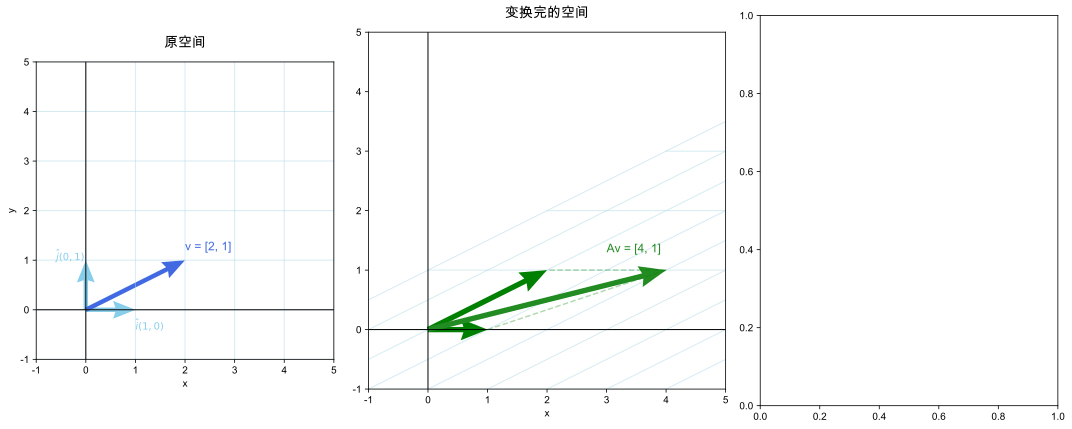

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# --- 1. 设置画布与风格 ---
# 设置风格，去掉背景网格，我们自己画
plt.style.use('default') 
# plt.rc('font',family='SimHei')  #用来 Windows 正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] #用来 MacOS 正常显示中文标签
# 创建 1 行 3 列的子图，分别对应：输入空间、计算过程、输出空间
fig, axes = plt.subplots(1, 3, figsize=(15, 6), dpi=150, gridspec_kw={'width_ratios': [1, 1.2, 1]})

# 定义原始向量 v 和 变换矩阵 A
v = np.array([2, 1])
A = np.array([[1, 2], 
              [0, 1]])  # 这是一个剪切矩阵 (Shear Matrix)

# 计算变换后的向量 Av
v_trans = A @ v  # 结果应该是 [4, 1]

# --- 辅助函数：绘制漂亮的箭头 ---
def draw_vector(ax, vec, origin=[0, 0], color='blue', label=None):
    ax.quiver(origin[0], origin[1], vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=color, label=label, width=0.015, headwidth=4, headlength=5)

# --- 辅助函数：绘制变换后的网格 (核心难点) ---
def plot_transformed_grid(ax, matrix, x_range=(-2, 6), y_range=(-1, 4)):
    # 遍历 x 方向的垂直线
    for x in range(x_range[0], x_range[1] + 1):
        # 取两个端点，连成线
        p1 = matrix @ np.array([x, y_range[0]])
        p2 = matrix @ np.array([x, y_range[1]])
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='lightblue', alpha=0.5, linewidth=1, zorder=0)
    
    # 遍历 y 方向的水平线
    for y in range(y_range[0], y_range[1] + 1):
        p1 = matrix @ np.array([x_range[0], y])
        p2 = matrix @ np.array([x_range[1], y])
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='lightblue', alpha=0.5, linewidth=1, zorder=0)

# ==========================================
# 图 1: 输入向量空间 (左图)
# ==========================================
ax1 = axes[0]
ax1.set_title("原空间", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 5)
ax1.set_aspect('equal')

# 绘制标准网格
ax1.grid(color='lightblue', linestyle='-', linewidth=1, alpha=0.5)
ax1.axhline(0, color='black', linewidth=1) # x轴
ax1.axvline(0, color='black', linewidth=1) # y轴

# 绘制基向量 (i_hat, j_hat) - 浅色显示
draw_vector(ax1, [1, 0], color='skyblue')
draw_vector(ax1, [0, 1], color='skyblue')
ax1.text(1, -0.4, '$\hat{i}(1,0)$', color='skyblue', fontsize=10)
ax1.text(-0.6, 1, '$\hat{j}(0,1)$', color='skyblue', fontsize=10)

# 绘制输入向量 v
draw_vector(ax1, v, color='royalblue')
ax1.text(v[0], v[1]+0.2, f'v = {list(v)}', color='royalblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# # ==========================================
# # 图 2: 线性变换过程 (中图)
# # ==========================================
# ax2 = axes[1]
# ax2.axis('off') # 隐藏坐标轴

# # 添加背景框 (橙色背景)
# rect = patches.FancyBboxPatch((0.05, 0.1), 0.9, 0.8, boxstyle="round,pad=0.05", linewidth=2, edgecolor='#f39c12', facecolor='#fce5cd', transform=ax2.transAxes)
# ax2.add_patch(rect)

# # 标题
# ax2.text(0.5, 0.8, "Linear Transformation\nvia Matrix A", ha='center', va='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)

# # 数学公式 (LaTeX)
# equation = r"$\\mathbf{A} \\cdot \\mathbf{v} = \\begin{bmatrix} 1 & 2 \\\\ 0 & 1 \\end{bmatrix} \\begin{bmatrix} 2 \\\\ 1 \\end{bmatrix}$"
# # calculation = r"$= \\begin{bmatrix} 1*2 + 2*1 \\\\ 0*2 + 1*1 \\end{bmatrix} = \\begin{bmatrix} 4 \\\\ 1 \\end{bmatrix}$"

# equation = '$\\mathbf{A} \\cdot \\mathbf{v} = [ 1  2 \\ 0  1]  [ 2 \\ 1 ]$'

# ax2.text(0.5, 0.55, equation, ha='center', va='center', fontsize=16, transform=ax2.transAxes)
# # ax2.text(0.5, 0.35, calculation, ha='center', va='center', fontsize=16, transform=ax2.transAxes)

# # 底部说明文字
# ax2.text(0.5, 0.15, "Matrix A acts on vector v to\nproduce a new vector Av", ha='center', va='center', fontsize=11, style='italic', transform=ax2.transAxes)

# # 添加指向右边的箭头
# arrow = patches.FancyArrowPatch((0.96, 0.5), (1.1, 0.5), transform=ax2.transAxes, color='#e67e22', mutation_scale=20, linewidth=2)
# fig.patches.append(arrow) # 添加到整个figure层级，避免被裁切


# ==========================================
# 图 3: 变换后的向量空间 (右图)
# ==========================================
ax3 = axes[1]
ax3.set_title("变换完的空间", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlim(-1, 5)
ax3.set_ylim(-1, 5)
ax3.set_aspect('equal')

# 绘制变换后的坐标轴 (x轴不变，y轴倾斜)
origin = np.array([0, 0])
# 绘制黑色基准坐标轴
ax3.axhline(0, color='black', linewidth=1)
ax3.axvline(0, color='black', linewidth=1)

# 关键：绘制变换后的网格！
plot_transformed_grid(ax3, A)

# 绘制变换后的基向量 (i_new, j_new) - 虚线表示
i_new = A @ np.array([1, 0])
j_new = A @ np.array([0, 1])
draw_vector(ax3, i_new, color='green', label='Transformed i')
draw_vector(ax3, j_new, color='green', label='Transformed j')
# 用虚线连接，展示平行四边形法则
ax3.plot([v_trans[0], i_new[0]], [v_trans[1], i_new[1]], 'g--', alpha=0.3)
ax3.plot([v_trans[0], j_new[0]], [v_trans[1], j_new[1]], 'g--', alpha=0.3)

# 绘制最终结果向量 Av
draw_vector(ax3, v_trans, color='forestgreen')
ax3.text(v_trans[0]-1, v_trans[1]+0.3, f'Av = {list(v_trans)}', color='forestgreen', fontsize=12, fontweight='bold')

ax3.set_xlabel('x')
# ax3.set_ylabel('y') # 保持整洁，右图不一定要显示y轴标签

plt.tight_layout()
plt.show()

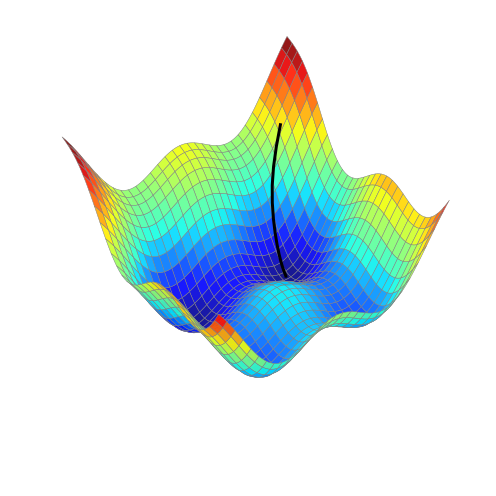

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 1. 定义目标函数 (Loss Function)
# 这是一个构造的函数：包含二次项（保证有一个全局趋势）和三角函数项（制造鞍点和波浪）
def f(x, y):
    # 0.1*(x^2 + y^2) 保证整体像个碗，有全局极小
    # sin/cos 部分制造局部的起伏和鞍点
    return 0.1 * (x**2 + y**2) + np.sin(x) + np.cos(y) 

# 2. 定义梯度 (Gradient)
def grad_f(x, y):
    df_dx = 0.2 * x + np.cos(x)
    df_dy = 0.2 * y - np.sin(y)
    return np.array([df_dx, df_dy])

# 3. 梯度下降算法 (Gradient Descent)
def gradient_descent(start_x, start_y, lr=0.1, epochs=50):
    path_x, path_y, path_z = [start_x], [start_y], [f(start_x, start_y)]
    x, y = start_x, start_y
    
    for _ in range(epochs):
        grad = grad_f(x, y)
        x = x - lr * grad[0]
        y = y - lr * grad[1]
        
        path_x.append(x)
        path_y.append(y)
        path_z.append(f(x, y))
        
    return np.array(path_x), np.array(path_y), np.array(path_z)

# --- 设置绘图数据 ---
# 生成网格数据
x_range = np.arange(-6, 6, 0.1)
y_range = np.arange(-6, 6, 0.1)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

# 执行梯度下降，获得路径
# 起点选在一个高处，能够经过一些起伏的位置
start_x, start_y = -4.5, 4.5
path_x, path_y, path_z = gradient_descent(start_x, start_y, lr=0.2, epochs=60)

# --- 开始绘图 ---
fig = plt.figure(figsize=(10, 7), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# 1. 绘制曲面 (Surface Plot)
# cmap='jet' 对应图中那种经典的红-蓝彩虹色
# rstride, cstride 控制网格的密度
# alpha 设置透明度
surf = ax.plot_surface(X, Y, Z, cmap='jet', 
                       linewidth=0.5,      # 线宽
                       edgecolor='gray',   # 网格线颜色（复刻图中的网格效果）
                       alpha=0.9,          # 不透明度
                       rstride=4, cstride=4) # 网格稀疏度，越小越密

# 2. 绘制梯度下降轨迹 (Trajectory)
ax.plot(path_x, path_y, path_z + 0.1, color='black', linewidth=3, zorder=10)

# 3. 绘制箭头 (Arrow)
# 在路径末端画一个箭头表示方向
ax.quiver(path_x[-2], path_y[-2], path_z[-2], 
          path_x[-1]-path_x[-2], path_y[-1]-path_y[-2], path_z[-1]-path_z[-2],
          color='black', length=1.5, arrow_length_ratio=3, lw=2)

# --- 视觉美化 ---
# 调整视角以匹配图片的俯视/侧视角度
ax.view_init(elev=45, azim=-35)

# 移除坐标轴刻度，让图看起来更像示意图
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off() # 如果想完全隐藏坐标轴背景，取消注释这行

plt.tight_layout()
plt.show()

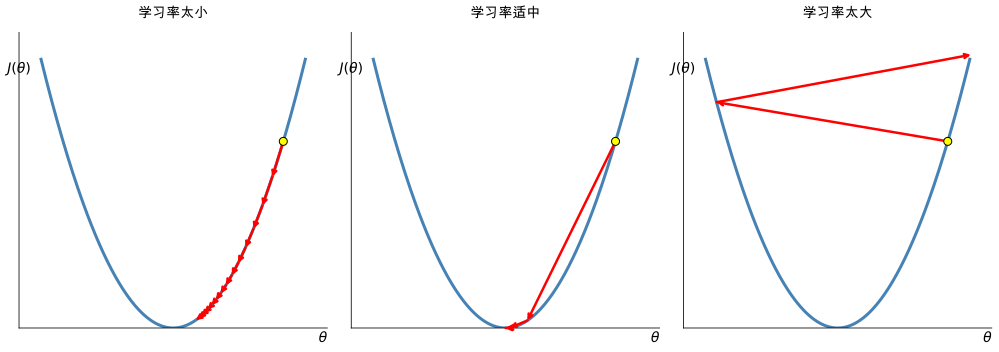

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 定义目标函数及其梯度 ---
# 这里使用一个简单的二次函数 J(theta) = (theta - 2)^2 作为示例
# 它的最小点在 theta = 2
def J_func(theta):
    return (theta - 2)**2

def grad_J_func(theta):
    # J'(theta) = 2 * (theta - 2)
    return 2 * (theta - 2)

# --- 2. 模拟梯度下降路径的函数 ---
def get_gd_path(start_theta, learning_rate, n_steps):
    path = [start_theta]
    curr_theta = start_theta
    for _ in range(n_steps):
        grad = grad_J_func(curr_theta)
        curr_theta = curr_theta - learning_rate * grad
        path.append(curr_theta)
        # 如果发散得太远就提前停止，防止画图溢出
        if abs(curr_theta) > 10: break 
    return np.array(path)

# --- 3. 绘图设置 ---
# 设置画布大小和子图结构 (1行3列)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 用于绘制背景曲线的网格点
theta_grid = np.linspace(-1, 5, 200)
J_grid = J_func(theta_grid)

# 统一的起始点 (参考原图，在右侧较高处)
start_theta = 4.5

# 定义三种情况的参数：(标题, 学习率, 步数)
scenarios = [
    ("学习率太小", 0.05, 15),  # 学习率太低，步子小，收敛慢
    ("学习率适中", 0.4, 5), # 学习率合适，快速收敛
    ("学习率太大", 1.05, 5)   # 学习率太高，在两侧震荡发散
]
# plt.rc('font',family='SimHei')  #用来 Windows 正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] #用来 MacOS 正常显示中文标签

# --- 4. 循环绘制三个子图 ---
for i, (ax, (title, lr, steps)) in enumerate(zip(axes, scenarios)):
    # a. 绘制背景蓝色曲线
    ax.plot(theta_grid, J_grid, color='steelblue', linewidth=3)

    # b. 获取梯度下降路径
    path_thetas = get_gd_path(start_theta, lr, steps)
    path_Js = J_func(path_thetas)

    # c. 绘制起始点 (黄色圆点)
    ax.plot(path_thetas[0], path_Js[0], marker='o', color='yellow', 
            markeredgecolor='black', markersize=8, zorder=10)

    # d. 绘制红色的梯度下降箭头路径
    # 使用 annotate 画箭头，连接路径上的每一步
    for j in range(len(path_thetas) - 1):
        # 起点 (当前位置)
        start_point = (path_thetas[j], path_Js[j])
        # 终点 (下一步位置)
        end_point = (path_thetas[j+1], path_Js[j+1])
        
        # 如果是 "Too high" 的情况，并且已经震荡到很远的地方，只画前面几步，避免图太乱
        if title == "太大" and j > 4: continue

        ax.annotate('', xy=end_point, xytext=start_point,
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5, 
                                    shrinkA=0, shrinkB=0)) # shrink防止箭头缩短

    # e. 美化图表样式 (模仿原图)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # 设置坐标轴标签
    ax.set_xlabel(r'$\theta$', fontsize=14, loc='right')
    # 将 J(theta) 标签放在左上角
    ax.text(-1.5, max(J_grid)*0.95, r'$J(\theta)$', fontsize=14, ha='center')

    # 移除刻度数字，使其看起来更像示意图
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 移除上方和右侧的边框线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 调整显示范围，确保"Too high"的箭头不会飞出太多
    ax.set_xlim(-1.5, 5.5)
    ax.set_ylim(0, max(J_grid) * 1.1)

# --- 5. 显示图像 ---
plt.tight_layout()
plt.show()